## 1. Final Comparisons
Here I compare the final results from:
1. Standard camera-only model  
2. Adversarially trained camera-only model  
3. Standard cross-attention fusion model  
4. Adversarially trained cross-attention fusion model  


## Import and labels

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

LABEL_NAMES = ["straight", "turn_left", "turn_right", "stop"]
NUM_CLASSES = 4

## 3. Paste Final Results

In [2]:
# Final 2×2 Results

# Use only the epsilons shared by both notebooks
EPSILONS = [0.00, 0.01, 0.03, 0.05, 0.10, 0.20, 0.30]

camera_standard = {
    "clean_acc": {
        0.00: 94.92,
        0.01: 94.92,
        0.03: 94.92,
        0.05: 94.92,
        0.10: 94.92,
        0.20: 94.92,
        0.30: 94.92,
    },
    "attack_acc": {
        0.00: 94.92,
        0.01: 26.55,
        0.03: 3.39,
        0.05: 3.95,
        0.10: 10.45,
        0.20: 26.84,
        0.30: 47.46,
    },
    "best_bal_val": 94.73
}

camera_adv = {
    "clean_acc": {
        0.00: 94.07,
        0.01: 94.07,
        0.03: 94.07,
        0.05: 94.07,
        0.10: 94.07,
        0.20: 94.07,
        0.30: 94.07,
    },
    "attack_acc": {
        0.00: 94.07,
        0.01: 70.62,
        0.03: 69.49,
        0.05: 77.12,
        0.10: 78.53,
        0.20: 76.55,
        0.30: 74.86,
    },
    "best_bal_val": 95.42
}

fusion_standard = {
    "clean_acc": {
        0.00: 92.94,
        0.01: 92.94,
        0.03: 92.94,
        0.05: 92.94,
        0.10: 92.94,
        0.20: 92.94,
        0.30: 92.94,
    },
    "attack_acc": {
        0.00: 92.94,
        0.01: 3.11,
        0.03: 0.28,
        0.05: 0.28,
        0.10: 0.28,
        0.20: 14.69,
        0.30: 41.53,
    },
    "best_bal_val": 93.40
}

fusion_adv = {
    "clean_acc": {
        0.00: 81.92,
        0.01: 81.92,
        0.03: 81.92,
        0.05: 81.92,
        0.10: 81.92,
        0.20: 81.92,
        0.30: 81.92,
    },
    "attack_acc": {
        0.00: 81.92,
        0.01: 81.07,
        0.03: 81.36,
        0.05: 81.36,
        0.10: 81.36,
        0.20: 81.07,
        0.30: 81.07,
    },
    "best_bal_val": 62.72
}

## 4. Final Comparison Table Across Epsilons

In [3]:
print("Final 2×2 Comparison Across FGSM Epsilon Values")
print("-" * 112)
print(
    f"{'Eps':>6} | "
    f"{'Cam Std Attack':>14} | "
    f"{'Cam Adv Attack':>14} | "
    f"{'Fusion Std Attack':>17} | "
    f"{'Fusion Adv Attack':>17} | "
    f"{'Best Model':>16}"
)
print("-" * 112)

for eps in EPSILONS:
    values = {
        "Cam Std": camera_standard["attack_acc"][eps],
        "Cam Adv": camera_adv["attack_acc"][eps],
        "Fusion Std": fusion_standard["attack_acc"][eps],
        "Fusion Adv": fusion_adv["attack_acc"][eps],
    }

    best_model = max(values, key=values.get)

    print(
        f"{eps:>6.2f} | "
        f"{values['Cam Std']:>13.2f}% | "
        f"{values['Cam Adv']:>13.2f}% | "
        f"{values['Fusion Std']:>16.2f}% | "
        f"{values['Fusion Adv']:>16.2f}% | "
        f"{best_model:>16}"
    )

Final 2×2 Comparison Across FGSM Epsilon Values
----------------------------------------------------------------------------------------------------------------
   Eps | Cam Std Attack | Cam Adv Attack | Fusion Std Attack | Fusion Adv Attack |       Best Model
----------------------------------------------------------------------------------------------------------------
  0.00 |         94.92% |         94.07% |            92.94% |            81.92% |          Cam Std
  0.01 |         26.55% |         70.62% |             3.11% |            81.07% |       Fusion Adv
  0.03 |          3.39% |         69.49% |             0.28% |            81.36% |       Fusion Adv
  0.05 |          3.95% |         77.12% |             0.28% |            81.36% |       Fusion Adv
  0.10 |         10.45% |         78.53% |             0.28% |            81.36% |       Fusion Adv
  0.20 |         26.84% |         76.55% |            14.69% |            81.07% |       Fusion Adv
  0.30 |         47.46% | 

## 5. Attack Accuracy Curve

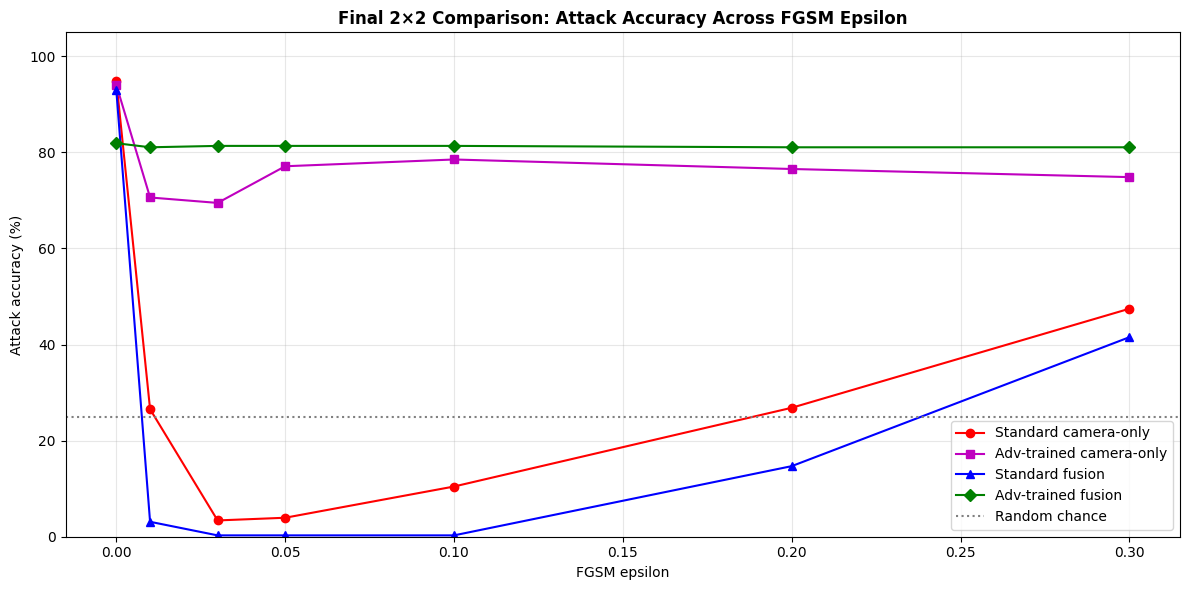

In [4]:
plt.figure(figsize=(12, 6))

cam_std_attack = [camera_standard["attack_acc"][eps] for eps in EPSILONS]
cam_adv_attack = [camera_adv["attack_acc"][eps] for eps in EPSILONS]
fusion_std_attack = [fusion_standard["attack_acc"][eps] for eps in EPSILONS]
fusion_adv_attack = [fusion_adv["attack_acc"][eps] for eps in EPSILONS]

plt.plot(EPSILONS, cam_std_attack, "r-o", label="Standard camera-only")
plt.plot(EPSILONS, cam_adv_attack, "m-s", label="Adv-trained camera-only")
plt.plot(EPSILONS, fusion_std_attack, "b-^", label="Standard fusion")
plt.plot(EPSILONS, fusion_adv_attack, "g-D", label="Adv-trained fusion")

plt.axhline(25, linestyle=":", color="gray", label="Random chance")

plt.title("Final 2×2 Comparison: Attack Accuracy Across FGSM Epsilon", fontweight="bold")
plt.xlabel("FGSM epsilon")
plt.ylabel("Attack accuracy (%)")
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("/content/final_2x2_attack_accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Clean vs Attack Table at Epsilon = 0.05

In [5]:
EPS = 0.05

summary_rows = [
    {
        "Model": "Standard camera-only",
        "Clean": camera_standard["clean_acc"][EPS],
        "Attack": camera_standard["attack_acc"][EPS],
        "Best Balanced Val": camera_standard["best_bal_val"],
    },
    {
        "Model": "Adv-trained camera-only",
        "Clean": camera_adv["clean_acc"][EPS],
        "Attack": camera_adv["attack_acc"][EPS],
        "Best Balanced Val": camera_adv["best_bal_val"],
    },
    {
        "Model": "Standard fusion",
        "Clean": fusion_standard["clean_acc"][EPS],
        "Attack": fusion_standard["attack_acc"][EPS],
        "Best Balanced Val": fusion_standard["best_bal_val"],
    },
    {
        "Model": "Adv-trained fusion",
        "Clean": fusion_adv["clean_acc"][EPS],
        "Attack": fusion_adv["attack_acc"][EPS],
        "Best Balanced Val": fusion_adv["best_bal_val"],
    },
]

print(f"Final 2×2 Clean vs Attack Summary at epsilon={EPS}")
print("-" * 95)
print(
    f"{'Model':>28} | "
    f"{'Clean Acc':>10} | "
    f"{'Attack Acc':>10} | "
    f"{'Drop':>10} | "
    f"{'Best Bal Val':>12}"
)
print("-" * 95)

for row in summary_rows:
    drop = row["Attack"] - row["Clean"]
    print(
        f"{row['Model']:>28} | "
        f"{row['Clean']:>9.2f}% | "
        f"{row['Attack']:>9.2f}% | "
        f"{drop:>+9.2f}% | "
        f"{row['Best Balanced Val']:>11.2f}%"
    )

Final 2×2 Clean vs Attack Summary at epsilon=0.05
-----------------------------------------------------------------------------------------------
                       Model |  Clean Acc | Attack Acc |       Drop | Best Bal Val
-----------------------------------------------------------------------------------------------
        Standard camera-only |     94.92% |      3.95% |    -90.97% |       94.73%
     Adv-trained camera-only |     94.07% |     77.12% |    -16.95% |       95.42%
             Standard fusion |     92.94% |      0.28% |    -92.66% |       93.40%
          Adv-trained fusion |     81.92% |     81.36% |     -0.56% |       62.72%


## 7. Bar chart at epsilon = 0.05

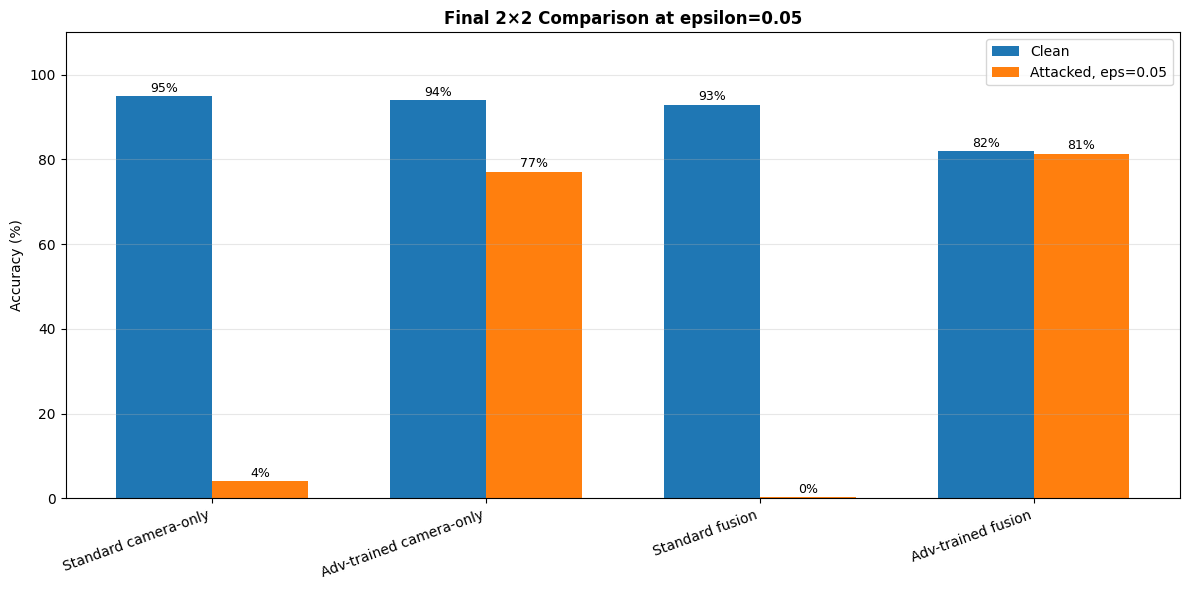

In [6]:
models = [row["Model"] for row in summary_rows]
clean_values = [row["Clean"] for row in summary_rows]
attack_values = [row["Attack"] for row in summary_rows]

x = np.arange(len(models))
w = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - w/2, clean_values, width=w, label="Clean")
plt.bar(x + w/2, attack_values, width=w, label=f"Attacked, eps={EPS}")

plt.xticks(x, models, rotation=20, ha="right")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.title("Final 2×2 Comparison at epsilon=0.05", fontweight="bold")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for i in range(len(models)):
    plt.text(x[i] - w/2, clean_values[i] + 1, f"{clean_values[i]:.0f}%", ha="center", fontsize=9)
    plt.text(x[i] + w/2, attack_values[i] + 1, f"{attack_values[i]:.0f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/final_2x2_bar_eps005.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Per-class results at epsilon = 0.05

In [7]:
EPS = 0.05

class_counts = {
    "straight": 237,
    "turn_left": 41,
    "turn_right": 32,
    "stop": 44,
}

per_class_attack = {
    "Standard camera-only": {
        "straight": 5.91,
        "turn_left": 0.00,
        "turn_right": 0.00,
        "stop": 0.00,
    },
    "Adv-trained camera-only": {
        "straight": 86.50,
        "turn_left": 29.27,
        "turn_right": 43.75,
        "stop": 95.45,
    },
    "Standard fusion": {
        "straight": 0.00,
        "turn_left": 0.00,
        "turn_right": 0.00,
        "stop": 0.00,
    },
    "Adv-trained fusion": {
        "straight": 94.00,
        "turn_left": 51.00,
        "turn_right": 3.00,
        "stop": 100.00,
    }
}

## 9. Per-class final comparison table

In [8]:
print(f"Final 2×2 Per-Class Attack Accuracy at epsilon={EPS}")
print("-" * 105)
print(
    f"{'Class':>12} | {'N':>5} | "
    f"{'Cam Std':>9} | {'Cam Adv':>9} | "
    f"{'Fusion Std':>11} | {'Fusion Adv':>11} | "
    f"{'Best':>12}"
)
print("-" * 105)

for cls in LABEL_NAMES:
    values = {
        "Cam Std": per_class_attack["Standard camera-only"][cls],
        "Cam Adv": per_class_attack["Adv-trained camera-only"][cls],
        "Fusion Std": per_class_attack["Standard fusion"][cls],
        "Fusion Adv": per_class_attack["Adv-trained fusion"][cls],
    }

    best_model = max(values, key=values.get)

    print(
        f"{cls:>12} | "
        f"{class_counts[cls]:>5} | "
        f"{values['Cam Std']:>8.2f}% | "
        f"{values['Cam Adv']:>8.2f}% | "
        f"{values['Fusion Std']:>10.2f}% | "
        f"{values['Fusion Adv']:>10.2f}% | "
        f"{best_model:>12}"
    )

Final 2×2 Per-Class Attack Accuracy at epsilon=0.05
---------------------------------------------------------------------------------------------------------
       Class |     N |   Cam Std |   Cam Adv |  Fusion Std |  Fusion Adv |         Best
---------------------------------------------------------------------------------------------------------
    straight |   237 |     5.91% |    86.50% |       0.00% |      94.00% |   Fusion Adv
   turn_left |    41 |     0.00% |    29.27% |       0.00% |      51.00% |   Fusion Adv
  turn_right |    32 |     0.00% |    43.75% |       0.00% |       3.00% |      Cam Adv
        stop |    44 |     0.00% |    95.45% |       0.00% |     100.00% |   Fusion Adv


## 10. Per-class bar chart

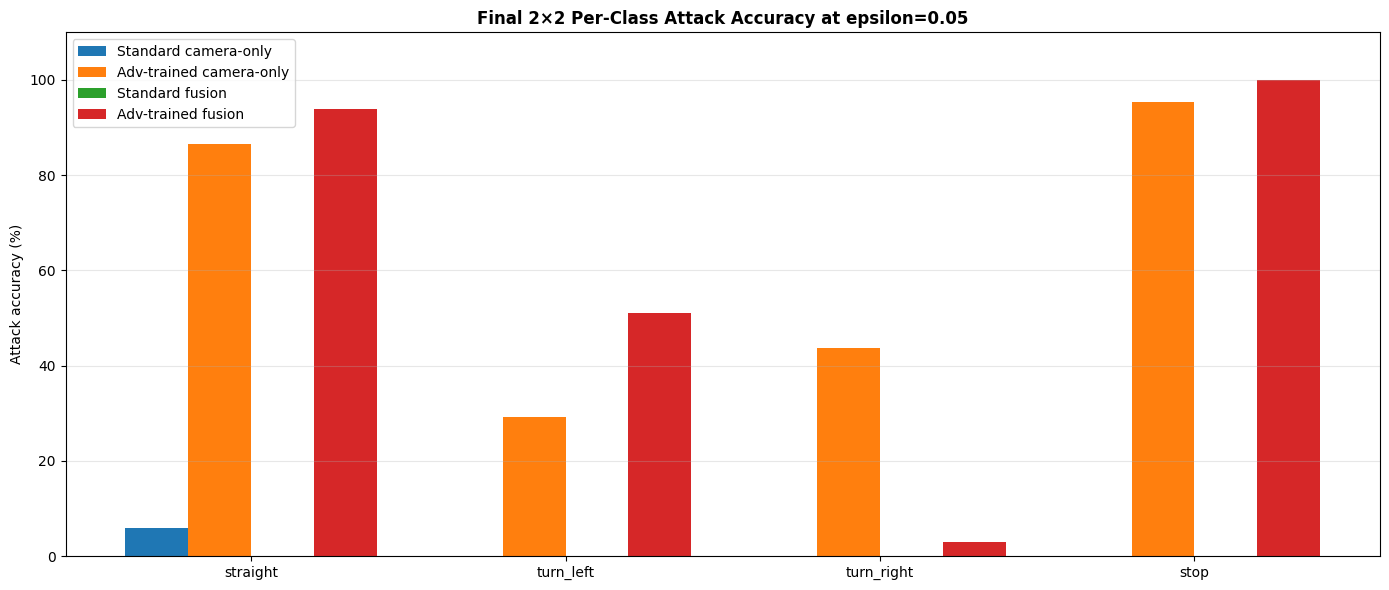

In [9]:
x = np.arange(NUM_CLASSES)
w = 0.20

cam_std_pc = [per_class_attack["Standard camera-only"][cls] for cls in LABEL_NAMES]
cam_adv_pc = [per_class_attack["Adv-trained camera-only"][cls] for cls in LABEL_NAMES]
fusion_std_pc = [per_class_attack["Standard fusion"][cls] for cls in LABEL_NAMES]
fusion_adv_pc = [per_class_attack["Adv-trained fusion"][cls] for cls in LABEL_NAMES]

plt.figure(figsize=(14, 6))

plt.bar(x - 1.5*w, cam_std_pc, width=w, label="Standard camera-only")
plt.bar(x - 0.5*w, cam_adv_pc, width=w, label="Adv-trained camera-only")
plt.bar(x + 0.5*w, fusion_std_pc, width=w, label="Standard fusion")
plt.bar(x + 1.5*w, fusion_adv_pc, width=w, label="Adv-trained fusion")

plt.xticks(x, LABEL_NAMES)
plt.ylabel("Attack accuracy (%)")
plt.ylim(0, 110)
plt.title("Final 2×2 Per-Class Attack Accuracy at epsilon=0.05", fontweight="bold")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/final_2x2_per_class_eps005.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Final interpretation helper

In [10]:
EPS = 0.05

cam_std_attack = camera_standard["attack_acc"][EPS]
cam_adv_attack = camera_adv["attack_acc"][EPS]
fusion_std_attack = fusion_standard["attack_acc"][EPS]
fusion_adv_attack = fusion_adv["attack_acc"][EPS]

cam_std_clean = camera_standard["clean_acc"][EPS]
cam_adv_clean = camera_adv["clean_acc"][EPS]
fusion_std_clean = fusion_standard["clean_acc"][EPS]
fusion_adv_clean = fusion_adv["clean_acc"][EPS]

print("Final Interpretation at epsilon=0.05")
print("-" * 60)

print(f"Standard camera-only: clean={cam_std_clean:.2f}%, attack={cam_std_attack:.2f}%")
print(f"Adv-trained camera-only: clean={cam_adv_clean:.2f}%, attack={cam_adv_attack:.2f}%")
print(f"Standard fusion: clean={fusion_std_clean:.2f}%, attack={fusion_std_attack:.2f}%")
print(f"Adv-trained fusion: clean={fusion_adv_clean:.2f}%, attack={fusion_adv_attack:.2f}%")

print()
print("Key differences:")
print(f"Adversarial training gain for camera-only: {cam_adv_attack - cam_std_attack:+.2f}%")
print(f"Adversarial training gain for fusion: {fusion_adv_attack - fusion_std_attack:+.2f}%")
print(f"Fusion gain without adversarial training: {fusion_std_attack - cam_std_attack:+.2f}%")
print(f"Fusion gain with adversarial training: {fusion_adv_attack - cam_adv_attack:+.2f}%")
print(f"Clean accuracy difference, adv fusion vs adv camera-only: {fusion_adv_clean - cam_adv_clean:+.2f}%")

Final Interpretation at epsilon=0.05
------------------------------------------------------------
Standard camera-only: clean=94.92%, attack=3.95%
Adv-trained camera-only: clean=94.07%, attack=77.12%
Standard fusion: clean=92.94%, attack=0.28%
Adv-trained fusion: clean=81.92%, attack=81.36%

Key differences:
Adversarial training gain for camera-only: +73.17%
Adversarial training gain for fusion: +81.08%
Fusion gain without adversarial training: -3.67%
Fusion gain with adversarial training: +4.24%
Clean accuracy difference, adv fusion vs adv camera-only: -12.15%


## 12. Save to Google Drive

In [12]:
import os
import shutil
import pickle
import zipfile

EXPERIMENT_NAME = "Final_2x2_Comparison"

use_drive = False

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    SAVE_DIR = f"/content/drive/MyDrive/AV_Adversarial_Project/{EXPERIMENT_NAME}"
    use_drive = True
    print("Google Drive mounted successfully.")
except Exception as e:
    print("Google Drive mount failed.")
    print("Saving locally instead.")
    print("Error:", e)
    SAVE_DIR = f"/content/{EXPERIMENT_NAME}"

os.makedirs(SAVE_DIR, exist_ok=True)

print(f"\nSaving to: {SAVE_DIR}")
print("-" * 70)

results_to_save = {
    "EPSILONS": EPSILONS,
    "camera_standard": camera_standard,
    "camera_adv": camera_adv,
    "fusion_standard": fusion_standard,
    "fusion_adv": fusion_adv,
    "summary_rows": summary_rows,
    "per_class_attack": per_class_attack,
    "class_counts": class_counts,
    "LABEL_NAMES": LABEL_NAMES,
}

with open(os.path.join(SAVE_DIR, "final_2x2_results.pkl"), "wb") as f:
    pickle.dump(results_to_save, f)

print("Saved result dictionary:")
print("  final_2x2_results.pkl")

files_to_copy = [
    "final_2x2_attack_accuracy_curve.png",
    "final_2x2_bar_eps005.png",
    "final_2x2_per_class_eps005.png",
]

saved_files = []

for fname in files_to_copy:
    src = os.path.join("/content", fname)
    dst = os.path.join(SAVE_DIR, fname)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        saved_files.append(fname)

print("\nSaved figures:")
if saved_files:
    for fname in saved_files:
        print(f"  {fname}")
else:
    print("  No figures found. Make sure you ran the plotting cells first.")

summary_path = os.path.join(SAVE_DIR, "save_summary.txt")

with open(summary_path, "w") as f:
    f.write(f"Experiment: {EXPERIMENT_NAME}\n")
    f.write(f"Save directory: {SAVE_DIR}\n\n")

    f.write("Saved figures:\n")
    for fname in saved_files:
        f.write(f"- {fname}\n")

    f.write("\nMain epsilon=0.05 results:\n")
    for row in summary_rows:
        f.write(
            f"{row['Model']}: clean={row['Clean']:.2f}%, "
            f"attack={row['Attack']:.2f}%\n"
        )

print(f"\nSummary saved:")
print(f"  {summary_path}")

if not use_drive:
    zip_path = f"/content/{EXPERIMENT_NAME}.zip"

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(SAVE_DIR):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, SAVE_DIR)
                zipf.write(file_path, arcname)

    print(f"\nGoogle Drive was not available, so a ZIP was created:")
    print(zip_path)

    try:
        from google.colab import files
        files.download(zip_path)
    except Exception as e:
        print("Automatic download failed.")
        print("You can manually download the ZIP from the Colab file panel.")
        print("Error:", e)

print("\nDone.")

Mounted at /content/drive
Google Drive mounted successfully.

Saving to: /content/drive/MyDrive/AV_Adversarial_Project/Final_2x2_Comparison
----------------------------------------------------------------------
Saved result dictionary:
  final_2x2_results.pkl

Saved figures:
  final_2x2_attack_accuracy_curve.png
  final_2x2_bar_eps005.png
  final_2x2_per_class_eps005.png

Summary saved:
  /content/drive/MyDrive/AV_Adversarial_Project/Final_2x2_Comparison/save_summary.txt

Done.
